# RFE → GCN Pipeline Test

**Question:** Does RFE as feature selector threaten the main paper result (SC 0.6644)?

| Pipeline | Stage | Expected |
|----------|-------|----------|
| AISO(Smart) → AISO | SC | 0.6644 (paper best) |
| RFE → SGD → GCN | SB | ? |
| RFE → AISO(Smart) → GCN | SC | ? |

Protocol: N_illicit=1000, N_licit=10000, 2-layer GCN, 5 seeds, PR-AUC.

> **Kernel:** Python312 (torch 2.11 + PyG 2.7)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

DATA_DIR  = Path('../Elliptic Bitcoin/elliptic_bitcoin_dataset')
K_SELECT  = 20
N_TYPES   = 15
N_ILLICIT = 1000
N_LICIT   = 10000
SEEDS     = [0, 7, 42, 77, 123]
GAMMA     = 0.5
DEVICE    = torch.device('cpu')

print(f'torch {torch.__version__} | device {DEVICE}')

torch 2.11.0+cpu | device cpu


## 1. Data

In [2]:
feat_df  = pd.read_csv(DATA_DIR / 'elliptic_txs_features.csv', header=None)
cls_df   = pd.read_csv(DATA_DIR / 'elliptic_txs_classes.csv')
edge_df  = pd.read_csv(DATA_DIR / 'elliptic_txs_edgelist.csv')

N_FEAT = feat_df.shape[1] - 2
feat_df.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(N_FEAT)]
cls_df.columns  = ['txId', 'class']

df = feat_df.merge(cls_df, on='txId')
df = df[df['class'] != 'unknown'].copy()
df['label'] = (df['class'] == '1').astype(int)
df = df.reset_index(drop=True)

feat_cols = [f'f{i}' for i in range(N_FEAT)]
train_mask = df['timestep'] <= 34
test_mask  = df['timestep'] >  34

X_all = df[feat_cols].values.astype(float)
y_all = df['label'].values
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

train_idx = np.where(train_mask)[0]
test_idx  = np.where(test_mask)[0]

# node id mapping
txid2idx = {txid: i for i, txid in enumerate(df['txId'])}
edge_src, edge_dst = [], []
for _, row in edge_df.iterrows():
    if row['txId1'] in txid2idx and row['txId2'] in txid2idx:
        edge_src.append(txid2idx[row['txId1']])
        edge_dst.append(txid2idx[row['txId2']])

edge_index_full = torch.tensor([edge_src + edge_dst, edge_dst + edge_src], dtype=torch.long)

print(f'Nodes: {len(df)} | Train: {train_mask.sum()} | Test: {test_mask.sum()}')
print(f'Edges: {len(edge_src)} | illicit train: {y_train.sum()} | illicit test: {y_test.sum()}')

Nodes: 46564 | Train: 29894 | Test: 16670
Edges: 36624 | illicit train: 3462 | illicit test: 1083


## 2. GCN + evaluate_gnn

In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.lin(x)


def evaluate_gnn(feat_idx, illicit_sel, licit_sel, seed=42, label=''):
    torch.manual_seed(seed)
    np.random.seed(seed)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all[:, feat_idx])

    # subgraph: selected illicit + licit
    train_nodes = np.concatenate([illicit_sel, licit_sel])
    train_labels = np.concatenate([np.ones(len(illicit_sel)), np.zeros(len(licit_sel))]).astype(int)

    x_tensor    = torch.tensor(X_scaled, dtype=torch.float)
    y_tensor    = torch.tensor(y_all, dtype=torch.long)
    tr_mask_t   = torch.zeros(len(df), dtype=torch.bool)
    tr_mask_t[train_nodes] = True
    te_mask_t   = torch.tensor(test_mask.values, dtype=torch.bool)

    data = Data(x=x_tensor, edge_index=edge_index_full, y=y_tensor).to(DEVICE)

    model = GCN(len(feat_idx)).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    w     = torch.tensor([1.0, (len(licit_sel)/len(illicit_sel))], dtype=torch.float).to(DEVICE)

    best_loss, best_state, patience = float('inf'), None, 0
    for epoch in range(300):
        model.train()
        opt.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[tr_mask_t], data.y[tr_mask_t], weight=w)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss  = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience   = 0
        else:
            patience += 1
        if patience >= 15: break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        proba = F.softmax(model(data.x, data.edge_index), dim=1)[:, 1].cpu().numpy()

    pr_auc = average_precision_score(y_all[test_mask], proba[test_mask])
    print(f'  {label} seed={seed}: PR-AUC={pr_auc:.4f}')
    return pr_auc


print('GCN ready')

GCN ready


## 3. Feature Selectors

In [4]:
# RFE — deterministic, run once
print('RFE feature selection...')
estimator = LogisticRegression(class_weight='balanced', max_iter=300, C=1.0, solver='liblinear')
rfe = RFE(estimator=estimator, n_features_to_select=K_SELECT, step=5)
rfe.fit(X_train, y_train)
rfe_feat = np.where(rfe.support_)[0]
print(f'RFE selected: {rfe_feat[:10]}... ({len(rfe_feat)} features)')

# Smart M
print('\nBuilding Smart M...')
C_corr  = np.corrcoef(X_train.T)
C_abs   = np.abs(C_corr)
dist_mx = 1.0 - C_abs; np.fill_diagonal(dist_mx, 0.0)
clust   = AgglomerativeClustering(n_clusters=N_TYPES, metric='precomputed', linkage='average')
cl_lab  = clust.fit_predict(dist_mx)
MI_glob = mutual_info_classif(X_train, y_train, random_state=42)
m_MI    = np.array([MI_glob[cl_lab == k].mean() if (cl_lab == k).any() else 0.0 for k in range(N_TYPES)])
MI_norm = (m_MI - m_MI.min()) / (m_MI.max() - m_MI.min() + 1e-8)

M_smart = np.zeros((N_TYPES, N_TYPES))
for i in range(N_TYPES):
    for j in range(N_TYPES):
        fi = np.where(cl_lab == i)[0]; fj = np.where(cl_lab == j)[0]
        M_smart[i, j] = -1.0 if i == j else -np.mean(C_abs[np.ix_(fi, fj)]) + GAMMA * (MI_norm[j] - MI_norm[i])
print('Smart M ready')

RFE feature selection...
RFE selected: [ 4  9 13 17 21 24 27 30 45 59]... (20 features)

Building Smart M...
Smart M ready


## 4. Node Samplers

In [5]:
train_illicit_idx = train_idx[y_train == 1]
train_licit_idx   = train_idx[y_train == 0]

def sgd_select_nodes(feat_idx, seed=42):
    """Score illicit nodes with SGD, take top N_ILLICIT."""
    rng = np.random.RandomState(seed)
    licit_sel = rng.choice(train_licit_idx, N_LICIT, replace=False)
    clf = SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=100, random_state=seed)
    clf.fit(X_train[:, feat_idx], y_train)
    scores = clf.predict_proba(X_all[train_illicit_idx][:, feat_idx])[:, 1]
    illicit_sel = train_illicit_idx[np.argsort(scores)[-N_ILLICIT:]]
    return illicit_sel, licit_sel


class AISOnodeSampler:
    def __init__(self, n_agents=20, n_iter=80, beta=0.15, subsample_ratio=0.15):
        self.n_agents = n_agents; self.n_iter = n_iter
        self.beta = beta; self.subsample_ratio = subsample_ratio

    def select(self, feat_idx, M, seed=42):
        rng  = np.random.RandomState(seed)
        pool = train_illicit_idx
        N    = len(pool)
        K    = M.shape[0]
        nb   = min(3, self.n_agents - 1)
        sub_n = max(50, int(self.subsample_ratio * N))

        # agent positions = indices into pool
        pos  = rng.choice(N, self.n_agents, replace=False)
        W    = rng.dirichlet(np.ones(K), self.n_agents)
        Wpool= rng.dirichlet(np.ones(K), N)  # type for each illicit node

        # score = SGD prob
        clf = SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=100, random_state=seed)
        clf.fit(X_train[:, feat_idx], y_train)
        all_scores = clf.predict_proba(X_all[pool][:, feat_idx])[:, 1]

        for t in range(self.n_iter):
            Cm = W @ M @ Wpool.T   # (n_agents, N)
            for i in range(self.n_agents):
                top = np.argsort(Cm[i])[-nb:]
                w_scores = Cm[i, top] * all_scores[top] / (all_scores[top].max() + 1e-8)
                bj = top[np.argmax(w_scores)]
                if all_scores[bj] > all_scores[pos[i]]:
                    pos[i] = bj
                W_new = (1 - self.beta) * W[i] + self.beta * Wpool[bj]
                W[i]  = W_new / W_new.sum()

        # score all pool nodes using final agent types
        final_scores = (W @ M @ Wpool.T).max(axis=0) * all_scores
        illicit_sel  = pool[np.argsort(final_scores)[-N_ILLICIT:]]
        licit_sel    = rng.choice(train_licit_idx, N_LICIT, replace=False)
        return illicit_sel, licit_sel


print('Node samplers ready')

Node samplers ready


## 5. Run Pipelines

In [6]:
results = {}

# --- Pipeline A: RFE → SGD → GCN (SB) ---
print('=== RFE → SGD → GCN (SB) ===')
rfe_sgd_scores = []
for seed in SEEDS:
    illicit_sel, licit_sel = sgd_select_nodes(rfe_feat, seed=seed)
    pr = evaluate_gnn(rfe_feat, illicit_sel, licit_sel, seed=seed, label='RFE→SGD→GCN')
    rfe_sgd_scores.append(pr)
results['RFE→SGD→GCN'] = rfe_sgd_scores
print(f'Mean: {np.mean(rfe_sgd_scores):.4f} ± {np.std(rfe_sgd_scores):.4f}\n')

# --- Pipeline B: RFE → AISO(Smart) → GCN (SC) ---
print('=== RFE → AISO(Smart) → GCN (SC) ===')
sampler = AISOnodeSampler(n_agents=20, n_iter=80, beta=0.15)
rfe_aiso_scores = []
for seed in SEEDS:
    illicit_sel, licit_sel = sampler.select(rfe_feat, M_smart, seed=seed)
    pr = evaluate_gnn(rfe_feat, illicit_sel, licit_sel, seed=seed, label='RFE→AISO→GCN')
    rfe_aiso_scores.append(pr)
results['RFE→AISO→GCN'] = rfe_aiso_scores
print(f'Mean: {np.mean(rfe_aiso_scores):.4f} ± {np.std(rfe_aiso_scores):.4f}')

=== RFE → SGD → GCN (SB) ===
  RFE→SGD→GCN seed=0: PR-AUC=0.4360
  RFE→SGD→GCN seed=7: PR-AUC=0.1310
  RFE→SGD→GCN seed=42: PR-AUC=0.4051
  RFE→SGD→GCN seed=77: PR-AUC=0.3998
  RFE→SGD→GCN seed=123: PR-AUC=0.4045
Mean: 0.3553 ± 0.1129

=== RFE → AISO(Smart) → GCN (SC) ===
  RFE→AISO→GCN seed=0: PR-AUC=0.2554
  RFE→AISO→GCN seed=7: PR-AUC=0.3557
  RFE→AISO→GCN seed=42: PR-AUC=0.3283
  RFE→AISO→GCN seed=77: PR-AUC=0.2963
  RFE→AISO→GCN seed=123: PR-AUC=0.2896
Mean: 0.3051 ± 0.0343


## 6. Decision

Pipeline                    PR-AUC    std
---------------------------------------------
  AISO(Smart)→AISO [paper]   0.6644 0.0200
  mRMR→SGD [paper SB]       0.6348 0.0055
  RFE→SGD→GCN               0.3553 0.1129
  RFE→AISO→GCN              0.3051 0.0343

RFE→SGD→GCN vs paper best: 0.3553 vs 0.6644 → safe
RFE→AISO→GCN vs paper best: 0.3051 vs 0.6644 → safe


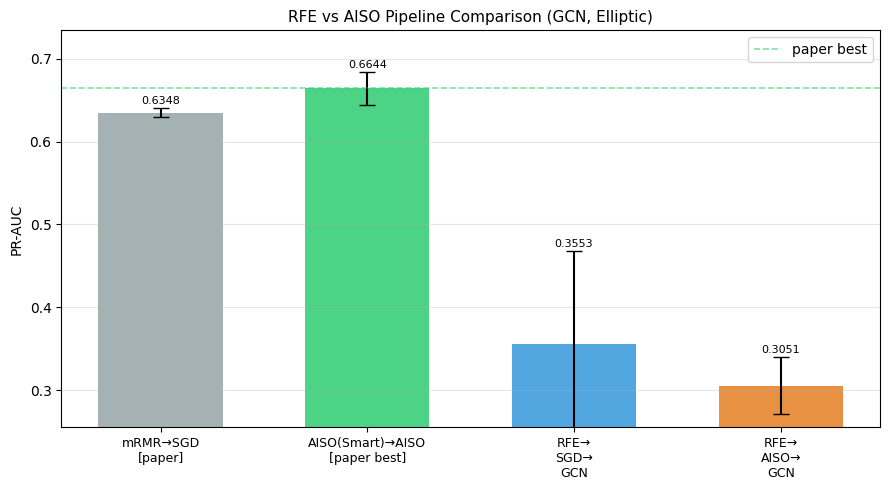

saved rfe_gcn_comparison.png


In [7]:
PAPER_BEST = 0.6644  # AISO(Smart)→AISO SC
PAPER_SB   = 0.6348  # mRMR→SGD

print(f'{'Pipeline':<25} {'PR-AUC':>8} {'std':>6}')
print('-' * 45)
print(f'  {'AISO(Smart)→AISO [paper]':<23} {PAPER_BEST:>8.4f} {0.0200:>6.4f}')
print(f'  {'mRMR→SGD [paper SB]':<23} {PAPER_SB:>8.4f} {0.0055:>6.4f}')
for name, scores in results.items():
    print(f'  {name:<23} {np.mean(scores):>8.4f} {np.std(scores):>6.4f}')

print()
for name, scores in results.items():
    m = np.mean(scores)
    beats = m > PAPER_BEST
    print(f'{name} vs paper best: {m:.4f} vs {PAPER_BEST:.4f} → {"THREAT" if beats else "safe"}')

import matplotlib.pyplot as plt
all_names  = ['mRMR→SGD\n[paper]', 'AISO(Smart)→AISO\n[paper best]'] + [n.replace('→', '→\n') for n in results]
all_means  = [PAPER_SB, PAPER_BEST] + [np.mean(results[n]) for n in results]
all_stds   = [0.0055, 0.0200] + [np.std(results[n]) for n in results]
colors     = ['#95a5a6', '#2ecc71', '#3498db', '#e67e22']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(all_names))
ax.bar(x, all_means, yerr=all_stds, capsize=6, color=colors, alpha=0.85, width=0.6)
ax.axhline(PAPER_BEST, color='#2ecc71', linestyle='--', linewidth=1.2, alpha=0.6, label='paper best')
ax.set_xticks(x); ax.set_xticklabels(all_names, fontsize=9)
ax.set_ylabel('PR-AUC'); ax.set_title('RFE vs AISO Pipeline Comparison (GCN, Elliptic)', fontsize=11)
ax.legend(); ax.grid(alpha=0.3, axis='y')
ymin = min(all_means) - 0.05; ymax = max(v+e for v,e in zip(all_means,all_stds)) + 0.05
ax.set_ylim(ymin, ymax)
for xi, (v, e) in enumerate(zip(all_means, all_stds)):
    ax.text(xi, v+e+0.005, f'{v:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('rfe_gcn_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('saved rfe_gcn_comparison.png')